# Candelaria Vial: priorización preventiva con datos abiertos

**Asignatura:** Técnicas de Aprendizaje de Máquina  
**Integrantes:** Completar nombres y códigos  
**Fuente principal:** [Accidentalidad Vial Municipio de Candelaria, Valle](https://www.datos.gov.co/Transporte/Accidentalidad-Vial-Municipio-de-Candelaria-Valle-/7wbf-88zm)

> **Nota de reproducibilidad.** Ejecutar el cuaderno de arriba hacia abajo y anotar la fecha de descarga: el conjunto abierto puede actualizarse.

## 1. Elevator pitch

La Secretaría de Tránsito y Transporte de Candelaria debe decidir dónde focalizar controles, señalización, inspecciones y educación vial. Decidir por intuición o por el accidente más reciente puede dispersar recursos escasos. Nuestra propuesta usa los registros históricos de siniestros para estimar el volumen mensual esperado por corregimiento y estudiar, con cautela, patrones de severidad por lugar y momento.

**Stakeholder:** Secretaría de Tránsito y Transporte de Candelaria, Valle del Cauca.  
**Costo de inacción:** intervenciones tardías o mal focalizadas; costos humanos, de atención y de movilidad.  
**Criterio de éxito:** superar un baseline temporal simple en el modelo mensual y no desplegar ningún modelo cuya validación temporal no sea discriminativa.

### Hipótesis

1. La frecuencia mensual de siniestros no es homogénea entre corregimientos.
2. Calendario, hora y ubicación aportan información sobre la severidad registrada.
3. Los siniestros recientes mejoran la priorización mensual frente al promedio histórico único.

## 2. IA como revisora crítica: definición del problema

**Prompt usado:**

> Actúa como directora de movilidad de Candelaria. Queremos priorizar intervenciones de seguridad vial con registros históricos de siniestros por vía, corregimiento, fecha, hora y gravedad. Dame cinco razones concretas para no financiar este proyecto, qué evidencia pedirías y qué daño podría causar un falso positivo o falso negativo.

**Respuesta crítica sintetizada:** (1) los registros pueden tener subregistro y cambios administrativos; (2) la vía y el corregimiento no prueban causalidad; (3) una predicción puede desplazar controles hacia barrios ya vigilados; (4) un modelo agregado no identifica conductas individuales; (5) sin comparación temporal con una regla simple, ML puede ser costo sin beneficio. Pediría cobertura por año, un baseline, evaluación fuera de tiempo y un protocolo de uso que prohíba sanciones o perfiles personales.

**Acciones del equipo:** se separa el último año para prueba, se agregan meses con cero siniestros al panel de regresión, se compara contra un baseline, se excluye `clase_de_accidente` del predictor preventivo y se define la app como apoyo a inspección, nunca como mecanismo sancionatorio.

In [1]:
# Instalación para Google Colab (ejecutar solo una vez)
!pip -q install pandas numpy scikit-learn seaborn plotly

import warnings
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score, average_precision_score, confusion_matrix, f1_score,
    mean_absolute_error, mean_squared_error, precision_score, r2_score,
    recall_score, roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42
DATA_URL = "https://www.datos.gov.co/resource/7wbf-88zm.csv?$limit=100000"
DOWNLOAD_TIME = datetime.now(timezone.utc).isoformat()

zsh:1: command not found: pip


Matplotlib is building the font cache; this may take a moment.


In [2]:
# Descarga reproducible desde la API Socrata
raw = pd.read_csv(DATA_URL)
expected_columns = {
    "clase_de_accidente", "gravedad", "vias", "corregimiento",
    "d_a_semana", "fecha_de_ocurrecia", "hora_ocurrencia",
}
assert expected_columns.issubset(raw.columns), "El esquema publicado cambió; revisar el diccionario."
print(f"Fecha UTC de descarga: {DOWNLOAD_TIME}")
print(f"Filas: {len(raw):,}; columnas: {raw.shape[1]}")
raw.head()

Fecha UTC de descarga: 2026-09-12T21:25:33.806656+00:00
Filas: 1,208; columnas: 7


,clase_de_accidente,gravedad,vias,corregimiento,d_a_semana,fecha_de_ocurrecia,hora_ocurrencia
0,CHOQUE,DAÑOS,CALI-CANDELARIA,VILLAGORGONA,VIERNES,1/01/2021,01:40:00
1,CHOQUE,MUERTOS,CALI-CANDELARIA,JUANCHITO,VIERNES,1/01/2021,15:00:00
2,CHOQUE,DAÑOS,CALI-CANDELARIA,JUANCHITO,DOMINGO,3/01/2021,17:08:00
3,CHOQUE,DAÑOS,CALI-CANDELARIA,VILLAGORGONA,DOMINGO,3/01/2021,12:45:00
4,CHOQUE,DAÑOS,CALI-CANDELARIA,EL CARMELO,DOMINGO,3/01/2021,07:00:00


## 3. Diccionario y calidad de los datos

| Campo | Tipo publicado | Uso y justificación |
| --- | --- | --- |
| `clase_de_accidente` | Texto/categórica | Variable descriptiva para EDA. Se excluye de los predictores preventivos porque puede incorporar información posterior al evento o una categorización que no estaría disponible al momento de priorizar. |
| `gravedad` | Texto/categórica | Variable objetivo del problema de clasificación; se transforma en `lesion_o_muerte` (HERIDOS/MUERTOS frente a DAÑOS). |
| `vias` | Texto/categórica | Contexto espacial del siniestro y predictor exploratorio de severidad. |
| `corregimiento` | Texto/categórica | Unidad territorial directamente accionable para la priorización mensual. |
| `d_a_semana` | Texto/categórica | Se contrasta con la fecha y se transforma a día numérico para modelado. |
| `fecha_de_ocurrecia` | Texto/fecha | Fuente para año, mes y periodo temporal; permite la partición cronológica. |
| `hora_ocurrencia` | Texto/hora | Se transforma a hora numérica y variables cíclicas para capturar patrones horarios. |
| `anio`, `mes`, `dia_semana_num`, `hora` | Numéricas derivadas | Variables de calendario obtenidas exclusivamente de fecha/hora. |
| `es_fin_de_semana` | Binaria derivada | Resume una condición temporal potencialmente útil para la priorización. |
| `mes_seno`, `mes_coseno`, `hora_seno`, `hora_coseno` | Numéricas derivadas | Representan la naturaleza cíclica de meses y horas sin imponer una distancia lineal artificial entre diciembre/enero o 23:00/00:00. |
| `siniestros_lag_1` | Numérica derivada | Número de siniestros del mes inmediatamente anterior en el mismo corregimiento; solo usa información pasada. |
| `promedio_3_meses_previo` | Numérica derivada | Promedio de los tres meses anteriores; resume tendencia reciente sin mirar el futuro. |
| `siniestros_mes` | Numérica objetivo | Conteo mensual de siniestros por corregimiento para el problema de regresión. |
| `lesion_o_muerte` | Binaria objetivo | Etiqueta de clasificación derivada de `gravedad`; no se utiliza como predictor. |

**Datos complementarios.** En esta versión no se incorporan fuentes externas: el objetivo es evaluar primero cuánto valor aporta el conjunto oficial por sí solo. Como trabajo futuro se propone integrar aforos/exposición vial, clima, obras, controles y geometría vial mediante llaves temporales y espaciales verificadas. La fuente es un registro administrativo; por ello, un cero o una frecuencia baja puede reflejar subregistro, no necesariamente ausencia absoluta de siniestros.


In [3]:
quality = pd.DataFrame({
    "tipo": raw.dtypes.astype(str),
    "nulos": raw.isna().sum(),
    "n_unicos": raw.nunique(dropna=True),
})
display(quality)
display(raw.duplicated().value_counts().rename("filas"))

,tipo,nulos,n_unicos
clase_de_accidente,object,2,6
gravedad,object,0,3
vias,object,0,113
corregimiento,object,0,36
d_a_semana,object,13,7
fecha_de_ocurrecia,object,0,857
hora_ocurrencia,object,13,186


False    1204
True        4
Name: filas, dtype: int64

In [4]:
def clean_text(series):
    return (series.fillna("SIN_DATO").astype(str).str.strip().str.upper()
            .replace({"": "SIN_DATO", "NAN": "SIN_DATO"}))

incidents = raw.copy()
for column in ["vias", "corregimiento", "d_a_semana", "gravedad", "clase_de_accidente"]:
    incidents[column] = clean_text(incidents[column])
incidents["fecha"] = pd.to_datetime(incidents["fecha_de_ocurrecia"], dayfirst=True, errors="coerce")
parsed_time = pd.to_timedelta(incidents["hora_ocurrencia"], errors="coerce")
incidents["hora"] = (parsed_time.dt.total_seconds() / 3600).fillna(12).clip(0, 23.99)
incidents = incidents.dropna(subset=["fecha"]).copy()
incidents["anio"] = incidents.fecha.dt.year.astype(int)
incidents["mes"] = incidents.fecha.dt.month.astype(int)
incidents["dia_semana_num"] = incidents.fecha.dt.dayofweek.astype(int)
incidents["es_fin_de_semana"] = (incidents.dia_semana_num >= 5).astype(int)
incidents["mes_seno"] = np.sin(2 * np.pi * incidents.mes / 12)
incidents["mes_coseno"] = np.cos(2 * np.pi * incidents.mes / 12)
incidents["hora_seno"] = np.sin(2 * np.pi * incidents.hora / 24)
incidents["hora_coseno"] = np.cos(2 * np.pi * incidents.hora / 24)
incidents["lesion_o_muerte"] = incidents.gravedad.isin(["HERIDOS", "MUERTOS"]).astype(int)

display(incidents[["fecha", "hora", "gravedad", "vias", "corregimiento"]].head())
print("Cobertura:", incidents.fecha.min().date(), "a", incidents.fecha.max().date())

,fecha,hora,gravedad,vias,corregimiento
0,2021-01-01,1.666667,DAÑOS,CALI-CANDELARIA,VILLAGORGONA
1,2021-01-01,15.000000,MUERTOS,CALI-CANDELARIA,JUANCHITO
2,2021-01-03,17.133333,DAÑOS,CALI-CANDELARIA,JUANCHITO
3,2021-01-03,12.750000,DAÑOS,CALI-CANDELARIA,VILLAGORGONA
4,2021-01-03,7.000000,DAÑOS,CALI-CANDELARIA,EL CARMELO


Cobertura: 2021-01-01 a 2025-12-02


## 4. EDA con narrativa

Cada gráfica responde a una decisión de negocio: ¿la cobertura es comparable por año?, ¿dónde conviene revisar primero?, ¿qué periodos conviene considerar en el plan preventivo? No se deben convertir correlaciones o conteos en afirmaciones de causalidad.

### IA como revisora crítica — EDA

**Prompt usado:**

> Estoy analizando un conjunto de accidentalidad vial para decidir dónde priorizar intervenciones. Mi EDA contiene conteos por año, mes, corregimiento y una tabla hora-día. ¿Qué análisis estadísticos mínimos faltan para evitar una narrativa puramente descriptiva y qué sesgos debo revisar?

**Crítica sintetizada:** faltaban medidas explícitas de tendencia central y dispersión, asimetría y correlaciones; además, los cambios interanuales no deben interpretarse como cambios reales de riesgo sin considerar cobertura y registro.

**Acción tomada:** se agregó una tabla con media, mediana, desviación estándar, IQR, mínimo, máximo y `skewness`, una matriz de correlaciones y una interpretación no causal de los patrones.


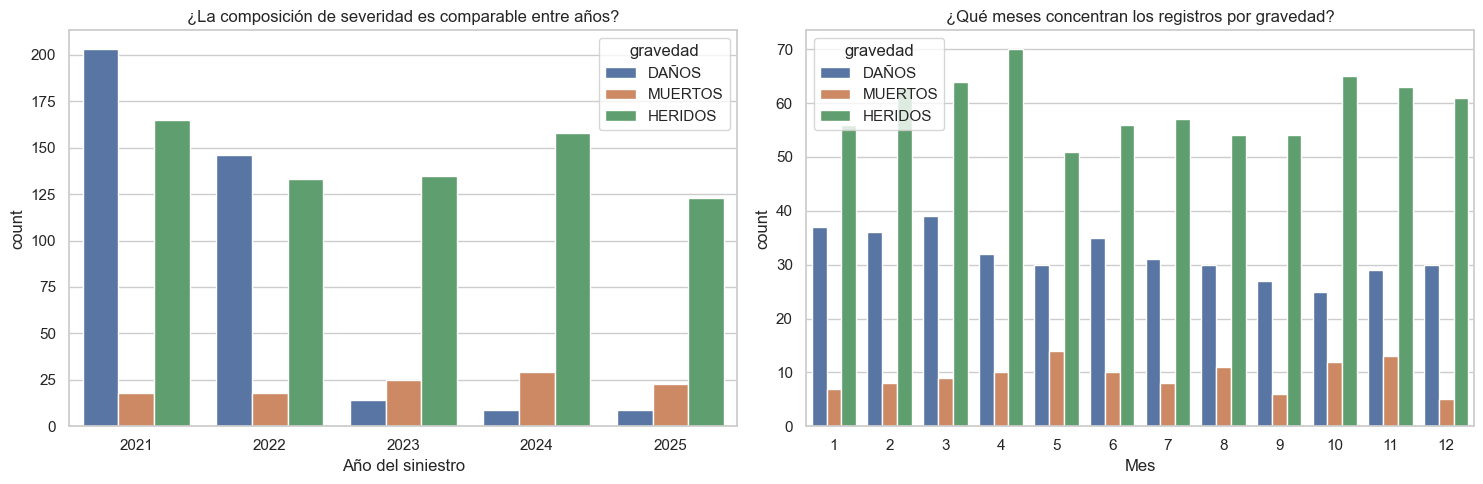

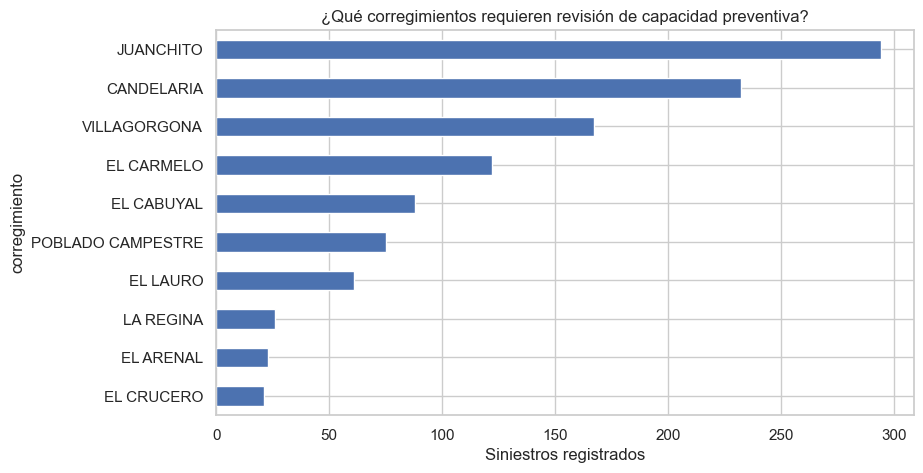

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(data=incidents, x="anio", hue="gravedad", ax=axes[0])
axes[0].set_title("¿La composición de severidad es comparable entre años?")
axes[0].set_xlabel("Año del siniestro")
sns.countplot(data=incidents, x="mes", hue="gravedad", ax=axes[1])
axes[1].set_title("¿Qué meses concentran los registros por gravedad?")
axes[1].set_xlabel("Mes")
plt.tight_layout()
plt.show()

top_locations = incidents.corregimiento.value_counts().head(10).sort_values()
ax = top_locations.plot.barh(figsize=(9, 5), title="¿Qué corregimientos requieren revisión de capacidad preventiva?")
ax.set_xlabel("Siniestros registrados")
plt.show()

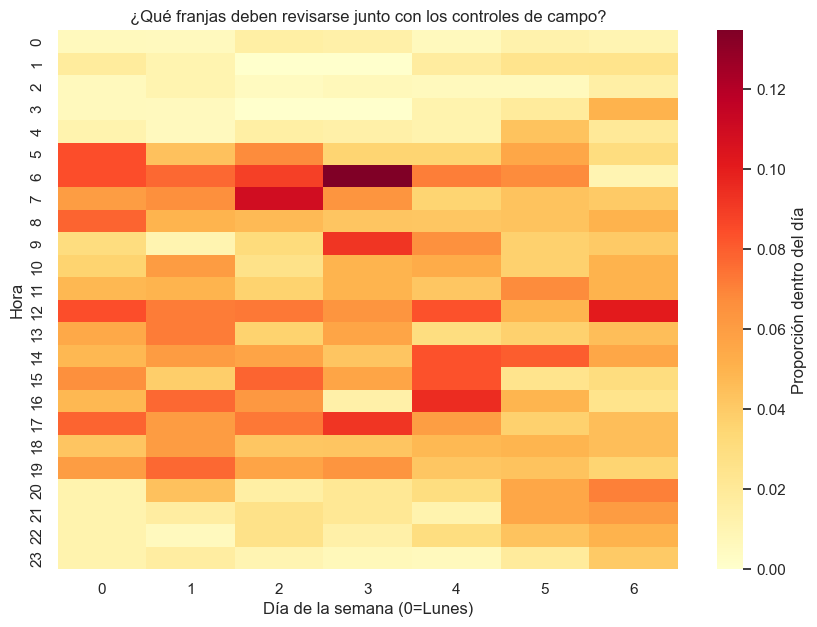

gravedad,DAÑOS,HERIDOS,MUERTOS
anio,,,
2021,0.526,0.427,0.047
2022,0.492,0.448,0.061
2023,0.080,0.776,0.144
2024,0.046,0.806,0.148
2025,0.058,0.794,0.148


In [6]:
pivot = pd.crosstab(incidents["hora"].astype(int), incidents["dia_semana_num"], normalize="columns")
plt.figure(figsize=(10, 7))
sns.heatmap(pivot, cmap="YlOrRd", cbar_kws={"label": "Proporción dentro del día"})
plt.title("¿Qué franjas deben revisarse junto con los controles de campo?")
plt.xlabel("Día de la semana (0=Lunes)")
plt.ylabel("Hora")
plt.show()

severity_year = pd.crosstab(incidents.anio, incidents.gravedad, normalize="index").round(3)
display(severity_year)

**Hallazgo inesperado a discutir.** Si la proporción de `DAÑOS`, `HERIDOS` o `MUERTOS` cambia abruptamente entre años, no se debe atribuir de inmediato a una mejora o deterioro vial: puede representar un cambio de registro. Esta posibilidad afecta sobre todo el modelo de severidad y debe comprobarse con la entidad publicadora.

In [7]:
# Panel completo corregimiento-mes: evita entrenar solo con meses que tuvieron siniestros.
start, end = incidents.fecha.min().to_period("M"), incidents.fecha.max().to_period("M")
periods = pd.period_range(start, end, freq="M")
locations = pd.DataFrame({"corregimiento": sorted(incidents.corregimiento.unique())})
monthly = locations.merge(pd.DataFrame({"periodo": periods}), how="cross")
monthly["fecha"] = monthly.periodo.dt.to_timestamp()
observed = (incidents.assign(periodo=incidents.fecha.dt.to_period("M"))
            .groupby(["corregimiento", "periodo"], as_index=False).size()
            .rename(columns={"size": "siniestros_mes"}))
monthly = monthly.merge(observed, on=["corregimiento", "periodo"], how="left")
monthly["siniestros_mes"] = monthly.siniestros_mes.fillna(0).astype(int)
monthly = monthly.sort_values(["corregimiento", "fecha"]).reset_index(drop=True)
groups = monthly.groupby("corregimiento", observed=True).siniestros_mes
monthly["siniestros_lag_1"] = groups.shift(1).fillna(0)
monthly["promedio_3_meses_previo"] = groups.transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean()).fillna(0)
monthly["anio"] = monthly.fecha.dt.year.astype(int)
monthly["mes"] = monthly.fecha.dt.month.astype(int)
monthly["mes_seno"] = np.sin(2 * np.pi * monthly.mes / 12)
monthly["mes_coseno"] = np.cos(2 * np.pi * monthly.mes / 12)
print(monthly.shape)
monthly.head()

(2160, 10)


,corregimiento,periodo,fecha,siniestros_mes,siniestros_lag_1,promedio_3_meses_previo,anio,mes,mes_seno,mes_coseno
0,BUCHITOLO,2021-01,2021-01-01,0,0.0,0.000000,2021,1,0.500000,8.660254e-01
1,BUCHITOLO,2021-02,2021-02-01,1,0.0,0.000000,2021,2,0.866025,5.000000e-01
2,BUCHITOLO,2021-03,2021-03-01,0,1.0,0.500000,2021,3,1.000000,6.123234e-17
3,BUCHITOLO,2021-04,2021-04-01,0,0.0,0.333333,2021,4,0.866025,-5.000000e-01
4,BUCHITOLO,2021-05,2021-05-01,0,0.0,0.333333,2021,5,0.500000,-8.660254e-01


In [ ]:
# Estadística descriptiva y sesgo: requisitos explícitos del EDA
# Pregunta: ¿qué tan disperso y asimétrico es el volumen de siniestros y qué variables numéricas
# podrían justificar transformaciones o cautela al interpretar relaciones?
eda_numeric = incidents[["anio", "mes", "dia_semana_num", "hora"]].describe().T
eda_numeric["mediana"] = incidents[["anio", "mes", "dia_semana_num", "hora"]].median()
eda_numeric["IQR"] = incidents[["anio", "mes", "dia_semana_num", "hora"]].quantile(0.75) - incidents[["anio", "mes", "dia_semana_num", "hora"]].quantile(0.25)
eda_numeric["sesgo_skew"] = incidents[["anio", "mes", "dia_semana_num", "hora"]].skew()
display(eda_numeric[["count", "mean", "std", "mediana", "IQR", "min", "max", "sesgo_skew"]].round(3))

# Correlaciones entre variables numéricas derivadas. Se interpretan como asociaciones, no causalidad.
corr_cols = ["mes", "dia_semana_num", "hora", "es_fin_de_semana", "mes_seno", "mes_coseno", "hora_seno", "hora_coseno", "lesion_o_muerte"]
corr = incidents[corr_cols].corr(numeric_only=True)
display(corr.round(3))
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", center=0)
plt.title("Correlaciones entre variables temporales y severidad")
plt.tight_layout()
plt.show()

# Tendencia central y dispersión del conteo mensual por corregimiento.
monthly_summary = monthly.groupby("corregimiento")["siniestros_mes"].agg(
    media="mean", mediana="median", desviacion="std", minimo="min", maximo="max"
).sort_values("media", ascending=False)
display(monthly_summary.round(3))


## 5. Preparación y partición temporal

Usamos el último año disponible solo para prueba. Los lags para la regresión se calculan con periodos anteriores. `clase_de_accidente`, muertes y cualquier consecuencia posterior no se usan como predictores preventivos.

### IA como revisora crítica — preparación de datos

**Prompt usado:**

> Para un modelo preventivo de accidentalidad, ¿qué riesgos de fuga de información o de construcción de variables debo revisar antes de entrenar? Evalúa especialmente variables derivadas de fecha, gravedad y conteos históricos.

**Crítica sintetizada:** no deben utilizarse consecuencias posteriores al siniestro como predictores preventivos; los lags deben construirse solo con periodos anteriores y la partición debe respetar el tiempo.

**Acción tomada:** se excluyó `clase_de_accidente` del predictor preventivo, la etiqueta `gravedad` no entra como predictor y los lags se calculan con `shift` antes de la partición temporal.


In [8]:
test_year = int(incidents.anio.max())
inc_train, inc_test = incidents[incidents.anio < test_year].copy(), incidents[incidents.anio == test_year].copy()
mon_train, mon_test = monthly[monthly.anio < test_year].copy(), monthly[monthly.anio == test_year].copy()
print(f"Entrenamiento: hasta {test_year - 1}; prueba: {test_year}")
print("Incidentes train/test:", inc_train.shape, inc_test.shape)
print("Panel mensual train/test:", mon_train.shape, mon_test.shape)

def preprocessor(categorical, numeric):
    return ColumnTransformer([
        ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                          ("ohe", OneHotEncoder(handle_unknown="ignore", min_frequency=5))]), categorical),
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                          ("scale", StandardScaler())]), numeric),
    ])

Entrenamiento: hasta 2024; prueba: 2025
Incidentes train/test: (1053, 18) (155, 18)
Panel mensual train/test: (1728, 10) (432, 10)


## 6. Problema 1 — regresión de siniestros mensuales

La salida es una cantidad esperada de siniestros en el corregimiento durante el mes. Se comparan tres algoritmos cubiertos por el curso y un baseline de promedio histórico. Para cumplir el requisito de optimización, se reserva el último año disponible para prueba y se utiliza el año inmediatamente anterior como validación temporal durante `RandomizedSearchCV`. La prueba final no participa en la selección de hiperparámetros.


### IA como revisora crítica — optimización e iteración

**Prompt usado:**

> Si un Random Forest supera al baseline en la prueba temporal, ¿basta con elegirlo? ¿Qué debería hacer para demostrar que la mejora no depende de hiperparámetros escogidos a mano y que no estoy usando el año de prueba para seleccionar el modelo?

**Crítica sintetizada:** no basta con comparar una configuración elegida manualmente; se necesita una validación temporal interna y dejar intacto el año de prueba.

**Acción tomada:** se añadió búsqueda de hiperparámetros sobre años anteriores al año de prueba, usando el año inmediatamente anterior como validación temporal, y se evalúan los parámetros elegidos una sola vez sobre el año de prueba.


In [9]:
from sklearn.model_selection import RandomizedSearchCV

reg_cat = ["corregimiento"]
reg_num = ["anio", "mes", "mes_seno", "mes_coseno", "siniestros_lag_1", "promedio_3_meses_previo"]
reg_features = reg_cat + reg_num
reg_models = {
    "Baseline: promedio histórico": DummyRegressor(strategy="mean"),
    "Ridge": Ridge(alpha=8.0),
    "Árbol de decisión": DecisionTreeRegressor(max_depth=6, min_samples_leaf=8, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=10, min_samples_leaf=4,
                                             max_features=0.8, n_jobs=-1, random_state=RANDOM_STATE),
}

# Primera comparación en el conjunto de entrenamiento completo contra el test final.
reg_fitted, reg_rows = {}, []
for name, estimator in reg_models.items():
    pipe = Pipeline([("prep", preprocessor(reg_cat, reg_num)), ("model", estimator)])
    pipe.fit(mon_train[reg_features], mon_train.siniestros_mes)
    pred = pipe.predict(mon_test[reg_features])
    reg_rows.append({"Modelo": name, "MAE": mean_absolute_error(mon_test.siniestros_mes, pred),
                     "RMSE": mean_squared_error(mon_test.siniestros_mes, pred) ** 0.5,
                     "R2": r2_score(mon_test.siniestros_mes, pred)})
    reg_fitted[name] = pipe
reg_results = pd.DataFrame(reg_rows).sort_values("MAE")
display(reg_results.round(4))

# Optimización temporal: el año previo al test funciona como validación.
reg_val_year = test_year - 1
reg_fit_tune = monthly[monthly.anio < reg_val_year].copy()
reg_val_tune = monthly[monthly.anio == reg_val_year].copy()
reg_search_spaces = {
    "Ridge": {"model__alpha": np.logspace(-2, 2, 20)},
    "Árbol de decisión": {
        "model__max_depth": [3, 4, 5, 6, 8, 10, None],
        "model__min_samples_leaf": [2, 4, 6, 8, 12, 16],
    },
    "Random Forest": {
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [5, 8, 10, 12, None],
        "model__min_samples_leaf": [2, 4, 6, 8],
        "model__max_features": [0.5, 0.8, 1.0],
    },
}

tuned_reg = {}
for name in ["Ridge", "Árbol de decisión", "Random Forest"]:
    pipe = Pipeline([("prep", preprocessor(reg_cat, reg_num)), ("model", reg_models[name])])
    # La selección se realiza con muestreo aleatorio de hiperparámetros y validación temporal explícita.
    from sklearn.model_selection import ParameterSampler
    sampled = list(ParameterSampler(reg_search_spaces[name], n_iter=10, random_state=RANDOM_STATE))
    best_mae, best_params = np.inf, None
    for params in sampled:
        candidate = Pipeline([("prep", preprocessor(reg_cat, reg_num)), ("model", reg_models[name])])
        candidate.set_params(**params)
        candidate.fit(reg_fit_tune[reg_features], reg_fit_tune.siniestros_mes)
        val_pred = candidate.predict(reg_val_tune[reg_features])
        mae = mean_absolute_error(reg_val_tune.siniestros_mes, val_pred)
        if mae < best_mae:
            best_mae, best_params = mae, params
    final_pipe = Pipeline([("prep", preprocessor(reg_cat, reg_num)), ("model", reg_models[name])])
    final_pipe.set_params(**best_params)
    final_pipe.fit(mon_train[reg_features], mon_train.siniestros_mes)
    tuned_reg[name] = final_pipe
    print(f"{name}: mejor validación temporal MAE={best_mae:.4f}; parámetros={best_params}")

# Evaluación final de los modelos optimizados en el año de prueba.
tuned_rows = []
for name, pipe in tuned_reg.items():
    pred = pipe.predict(mon_test[reg_features])
    tuned_rows.append({"Modelo optimizado": name,
                       "MAE": mean_absolute_error(mon_test.siniestros_mes, pred),
                       "RMSE": mean_squared_error(mon_test.siniestros_mes, pred) ** 0.5,
                       "R2": r2_score(mon_test.siniestros_mes, pred)})
tuned_reg_results = pd.DataFrame(tuned_rows).sort_values("MAE")
display(tuned_reg_results.round(4))


,Modelo,MAE,RMSE,R2
3,Random Forest,0.4446,0.7931,0.1385
2,Árbol de decisión,0.4598,0.8547,-0.0005
1,Ridge,0.4706,0.8468,0.0178
0,Baseline: promedio histórico,0.7171,0.8904,-0.0860


**Interpretación requerida:** compare la mejora absoluta y relativa de MAE frente al baseline. Un R² bajo no debe ocultarse: señala que faltan variables relevantes, como flujo vehicular, clima, obras, controles y exposición de actores viales. La salida solo sirve para orientar una revisión humana del territorio.


## 7. Problema 2 — clasificación de lesión o muerte

La etiqueta es `HERIDOS` o `MUERTOS` frente a `DAÑOS`. Esta tarea es exploratoria: si la composición de gravedad cambia entre años o el AUC no supera el baseline, no se lleva a la app. Reportar F1 **y** AUC-ROC/AUC-PR, pues accuracy y F1 pueden verse altos cuando una clase domina el año de prueba.

,Modelo,Accuracy,Precision,Recall,F1,AUC-ROC,AUC-PR
3,Random Forest,0.9419,0.9419,1.0000,0.9701,0.5670,0.9437
0,Baseline: clase mayoritaria,0.9419,0.9419,1.0000,0.9701,0.5000,0.9419
2,Árbol de decisión,0.8903,0.9448,0.9384,0.9416,0.4787,0.9375
1,Regresión logística,0.9419,0.9419,1.0000,0.9701,0.4140,0.9284


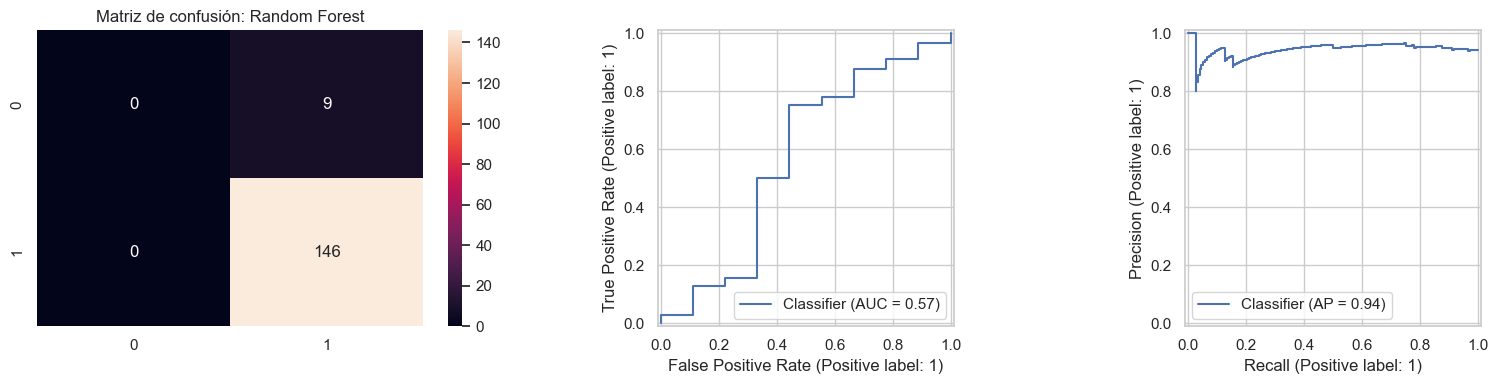

In [10]:
clf_cat = ["vias", "corregimiento"]
clf_num = ["anio", "mes", "dia_semana_num", "hora", "es_fin_de_semana", "mes_seno", "mes_coseno", "hora_seno", "hora_coseno"]
clf_features = clf_cat + clf_num
clf_models = {
    "Baseline: clase mayoritaria": DummyClassifier(strategy="prior"),
    "Regresión logística": LogisticRegression(C=0.5, class_weight="balanced", max_iter=2000,
                                                solver="liblinear", random_state=RANDOM_STATE),
    "Árbol de decisión": DecisionTreeClassifier(max_depth=6, min_samples_leaf=12,
                                                 class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=350, max_depth=12, min_samples_leaf=6,
                                              max_features=0.8, class_weight="balanced_subsample",
                                              n_jobs=-1, random_state=RANDOM_STATE),
}
clf_fitted, clf_rows = {}, []
for name, estimator in clf_models.items():
    pipe = Pipeline([("prep", preprocessor(clf_cat, clf_num)), ("model", estimator)])
    pipe.fit(inc_train[clf_features], inc_train.lesion_o_muerte)
    proba = pipe.predict_proba(inc_test[clf_features])[:, 1]
    label = (proba >= 0.5).astype(int)
    clf_rows.append({"Modelo": name, "Accuracy": accuracy_score(inc_test.lesion_o_muerte, label),
                     "Precision": precision_score(inc_test.lesion_o_muerte, label, zero_division=0),
                     "Recall": recall_score(inc_test.lesion_o_muerte, label, zero_division=0),
                     "F1": f1_score(inc_test.lesion_o_muerte, label, zero_division=0),
                     "AUC-ROC": roc_auc_score(inc_test.lesion_o_muerte, proba),
                     "AUC-PR": average_precision_score(inc_test.lesion_o_muerte, proba)})
    clf_fitted[name] = (pipe, proba)
clf_results = pd.DataFrame(clf_rows).sort_values("AUC-ROC", ascending=False)
display(clf_results.round(4))

best_name = clf_results.iloc[0].Modelo
best_pipe, best_proba = clf_fitted[best_name]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.heatmap(confusion_matrix(inc_test.lesion_o_muerte, best_proba >= .5), annot=True, fmt="d", ax=axes[0])
axes[0].set_title(f"Matriz de confusión: {best_name}")
RocCurveDisplay.from_predictions(inc_test.lesion_o_muerte, best_proba, ax=axes[1])
PrecisionRecallDisplay.from_predictions(inc_test.lesion_o_muerte, best_proba, ax=axes[2])
plt.tight_layout()
plt.show()

## 8. IA como revisora crítica: selección del modelo

**Prompt usado:**

> En la prueba temporal, la clasificación tiene F1 alto, pero AUC-ROC cercano a 0,5 y la clase de lesión o muerte domina el último año. ¿Es responsable seleccionar este modelo? ¿Qué explicaciones alternativas y decisiones recomendarías?

**Respuesta crítica sintetizada:** No. El F1 puede ser alto porque predecir siempre la clase mayoritaria funciona en ese corte. El cambio de composición puede ser un cambio de registro o de distribución. Recomienda mostrar baseline, AUC-ROC y AUC-PR, investigar calidad con la entidad, no publicar el clasificador y mantener la app limitada al problema mensual si este supera su baseline.

**Decisión del equipo:** se documenta el clasificador y sus límites porque es un requisito académico, pero se bloquea su uso en la app si AUC-ROC < 0,70. Se solicita validar con la entidad el cambio histórico de la categoría `DAÑOS`.

## 9. Ética, sesgos y limitaciones

- Los datos reflejan lo que se registra; no equivalen necesariamente a todos los siniestros.
- Una mayor frecuencia registrada puede reflejar mejor reporte o vigilancia, no mayor riesgo real.
- Vías y corregimientos pueden ser proxies de desigualdad. El producto debe asignar **apoyo preventivo**, nunca justificar estigmas, sanciones individuales o controles discriminatorios.
- Los lags requieren que la entidad actualice los conteos mensuales antes de usar la app.
- La herramienta no descubre causas ni responsabilidad: una inspección técnica y participación local son indispensables.

### IA como revisora crítica — aplicación web

**Prompt usado:**

> Mi aplicación muestra una predicción de siniestros mensuales a una Secretaría de Tránsito. ¿Qué necesita el usuario para confiar en ella y qué usos debería prohibir explícitamente?

**Crítica sintetizada:** una predicción aislada no es suficiente; la app debe explicar el alcance, mostrar factores relevantes y dejar claro que el resultado orienta revisión humana y no sanciones automáticas.

**Acción tomada:** la app mantiene acciones preventivas, explicabilidad y advertencias de uso; el clasificador de severidad no se presenta como herramienta operativa cuando su AUC no demuestra discriminación suficiente.


## 10. Conclusiones y trabajo futuro

El proyecto ofrece una ruta reproducible para priorizar inspecciones mensuales. La decisión de desplegar depende de la validación temporal, no de una métrica aislada. Próximos pasos: normalizar nombres de vías, conseguir exposición (aforo vehicular, peatones y ciclistas), clima, obras, controles y datos geográficos; validar los hallazgos con comunidad y Secretaría; medir la efectividad real de las intervenciones con un diseño cuasiexperimental.